In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [4]:
df = pd.read_csv("Global_Superstore2.csv", encoding='latin1', sep=',', quotechar='"', on_bad_lines='skip')

df.head()

/tmp/ipykernel_694/1016186385.py:1: DtypeWarning: Columns (0,11,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Global_Superstore2.csv", encoding='latin1', sep=',', quotechar='"', on_bad_lines='skip')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7.0,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9.0,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9.0,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5.0,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8.0,0.0,311.5200,903.04,Critical


In [5]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (84823, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84823 entries, 0 to 84822
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          84823 non-null  object 
 1   Order ID        84823 non-null  object 
 2   Order Date      84823 non-null  object 
 3   Ship Date       84823 non-null  object 
 4   Ship Mode       84823 non-null  object 
 5   Customer ID     84823 non-null  object 
 6   Customer Name   84823 non-null  object 
 7   Segment         84822 non-null  object 
 8   City            84822 non-null  object 
 9   State           84822 non-null  object 
 10  Country         84820 non-null  object 
 11  Postal Code     17068 non-null  object 
 12  Market          84818 non-null  object 
 13  Region          84818 non-null  object 
 14  Product ID      84818 non-null  object 
 15  Category        84818 non-null  object 
 16  Sub-Category    84818 non-null  object 
 17  Prod

In [6]:
print("Missing Values\n")

print(df.isnull().sum())

Missing Values

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               1
City                  1
State                 1
Country               3
Postal Code       67755
Market                5
Region                5
Product ID            5
Category              5
Sub-Category          5
Product Name          5
Sales                 5
Quantity              5
Discount              5
Profit                5
Shipping Cost         5
Order Priority        8
dtype: int64


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include="object").columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

for col in categorical_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

print("Missing values after cleaning:\n")
print(df.isnull().sum())

/tmp/ipykernel_694/2846164059.py:10: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  df[col].mode()[0]


Missing values after cleaning:

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Postal Code       0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After Removal:", df.shape)

Duplicate Rows: 16565
After Removal: (68258, 24)


In [9]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Sales"] < lower) |
    (df["Sales"] > upper)
]

print("Number of Sales Outliers:", len(outliers))

print(outliers[["Sales", "Profit"]].head())

Number of Sales Outliers: 8443
      Sales    Profit
0  2309.650  762.1845
1  3709.395 -288.7650
2  5175.171  919.9710
3  2892.510  -96.5400
4  2832.960  311.5200


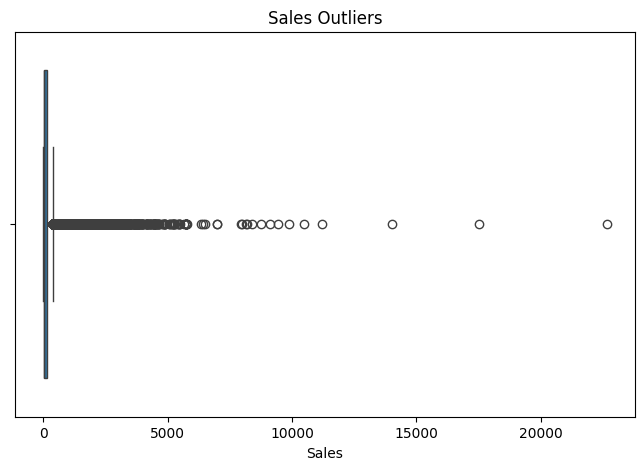

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Sales"])

plt.title("Sales Outliers")
plt.xlabel("Sales")

plt.show()

In [11]:
encoder = LabelEncoder()

df["Category"] = encoder.fit_transform(
    df["Category"]
)

print(df[["Category"]].head())

   Category
0         3
1         1
2         3
3         3
4         3
